# UV Index Forecasting - Modern & Foundation Models (Phase 4)
### Models: Facebook Prophet, TimeGPT (Nixtla), DeepSeek R1 (LLM Reasoning)
This notebook evaluates modern forecasting tools. TimeGPT and DeepSeek R1 are API-based so their sections include production-ready boilerplate code.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path('../../').resolve()))
from src.config import CORE_14_FEATURES

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet
import joblib

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
SEED = 42
np.random.seed(SEED)

# 1. Prepare Data for Prophet
Prophet requires the dataframe to have columns named `ds` (datetime) and `y` (target variable). We will use exogenous features as well.

In [2]:
DATA_DIR = Path('../../data/processed/features')
df = pd.read_csv(DATA_DIR / 'features_regression.csv', parse_dates=['timestamp'])

if 'uv_source' in df.columns:
    real_mask = df['uv_source'].isin(['weatherbit', 'open_meteo']) & df['uv_index'].notna()
    df = df[real_mask].copy()
    print(f'Filtered to real UV data: {len(df)} rows')
    print(f'Date range: {df["timestamp"].min()} -> {df["timestamp"].max()}')

TARGET = 'uv_index'
# ✅ Fix Bug #5 (typo 'relatie_humidity_2m') + Bug #6 (6 features → 14):
# Use the project-standard CORE_14_FEATURES from src.config
EXOG = CORE_14_FEATURES

LOCATIONS = sorted(df['location_id'].unique())

loc_data = {}
for loc in LOCATIONS:
    dl = df[df['location_id'] == loc].copy()
    dl.set_index('timestamp', inplace=True)
    dl = dl.sort_index()
    available_exog = [c for c in EXOG if c in dl.columns]
    dl = dl[[TARGET] + available_exog].interpolate(method='time').bfill()

    df_pr = dl.reset_index().rename(columns={'timestamp':'ds', TARGET: 'y'})

    from datetime import timedelta

    min_date = df_pr['ds'].min()
    max_date = df_pr['ds'].max()
    total_days = (max_date - min_date).days

    train_days = int(total_days * 0.70)
    val_days = int(total_days * 0.15)

    train_end = min_date + timedelta(days=train_days)
    val_end = train_end + timedelta(days=val_days)

    train = df_pr[(df_pr['ds'] >= min_date) & (df_pr['ds'] < train_end)].copy()
    val   = df_pr[(df_pr['ds'] >= train_end) & (df_pr['ds'] < val_end)].copy()
    test  = df_pr[df_pr['ds'] >= val_end].copy()

    loc_data[loc] = {
        'train': train, 'val': val, 'test': test,
        'y_val': val['y'].values, 'y_test': test['y'].values,
        'exog': available_exog
    }
    print(f'{loc.upper()}: Train={len(train)}, Val={len(val)}, Test={len(test)} | exog={len(available_exog)} features')

print(f'\n{len(LOCATIONS)} locations | EXOG: {len(EXOG)} features (CORE_14_FEATURES)')
missing = [c for c in EXOG if c not in df.columns]
if missing:
    print(f'  ⚠️  Missing from dataset: {missing}')


Filtered to real UV data: 386992 rows
Date range: 2015-06-23 07:00:00 -> 2026-04-21 23:00:00
CANGIO: Train=33926, Val=7355, Test=7197 | exog=10 features
CUCHI: Train=33943, Val=7360, Test=7197 | exog=10 features
DALAT: Train=33399, Val=7200, Test=7076 | exog=10 features
HCM: Train=33942, Val=7360, Test=7196 | exog=10 features
LONGHAI: Train=33883, Val=7340, Test=7186 | exog=10 features
NHABE: Train=33942, Val=7358, Test=7197 | exog=10 features


THUDUC: Train=33931, Val=7357, Test=7193 | exog=10 features
VUNGTAU: Train=33915, Val=7347, Test=7192 | exog=10 features

8 locations | EXOG: 14 features (CORE_14_FEATURES)
  ⚠️  Missing from dataset: ['cloud_cover_high', 'aerosol_optical_depth', 'pm2_5', 'precipitation']


# 2. Facebook Prophet (with Exogenous Variables)

In [3]:
print('Training Facebook Prophet across all locations...')
prophet_models = {}

for loc in LOCATIONS:
    d = loc_data[loc]
    exog = d['exog']
    m = Prophet(
        growth='linear',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=True,
        seasonality_mode='multiplicative',
    )
    for col in exog:
        m.add_regressor(col)
    m.fit(d['train'])
    prophet_models[loc] = m
    print(f' {loc.upper()}: Prophet trained with {len(exog)} regressors')

Training Facebook Prophet across all locations...


12:10:10 - cmdstanpy - INFO - Chain [1] start processing


12:10:28 - cmdstanpy - INFO - Chain [1] done processing


 CANGIO: Prophet trained with 10 regressors


12:10:29 - cmdstanpy - INFO - Chain [1] start processing


...

12:12:32 - cmdstanpy - INFO - Chain [1] done processing


 THUDUC: Prophet trained with 10 regressors


12:12:33 - cmdstanpy - INFO - Chain [1] start processing


12:12:51 - cmdstanpy - INFO - Chain [1] done processing


 VUNGTAU: Prophet trained with 10 regressors


# 3. Forecast and Evaluate Prophet

 Prophet_cangio [train] MAE: 0.3939, RMSE: 0.7015, R2: 0.86
 Prophet_cangio [val] MAE: 0.4625, RMSE: 0.8266, R2: 0.83
 Prophet_cangio [test] MAE: 0.3870, RMSE: 0.6940, R2: 0.85


 Prophet_cuchi [train] MAE: 0.3855, RMSE: 0.6689, R2: 0.86
 Prophet_cuchi [val] MAE: 0.4806, RMSE: 0.8245, R2: 0.83
 Prophet_cuchi [test] MAE: 0.4212, RMSE: 0.6969, R2: 0.85


 Prophet_dalat [train] MAE: 0.3507, RMSE: 0.6139, R2: 0.86
 Prophet_dalat [val] MAE: 0.3981, RMSE: 0.7615, R2: 0.83
 Prophet_dalat [test] MAE: 0.3043, RMSE: 0.6074, R2: 0.84


 Prophet_hcm [train] MAE: 0.3779, RMSE: 0.6554, R2: 0.87
 Prophet_hcm [val] MAE: 0.4714, RMSE: 0.7991, R2: 0.83
 Prophet_hcm [test] MAE: 0.4272, RMSE: 0.6922, R2: 0.85


 Prophet_longhai [train] MAE: 0.3853, RMSE: 0.6705, R2: 0.86
 Prophet_longhai [val] MAE: 0.4639, RMSE: 0.8221, R2: 0.83
 Prophet_longhai [test] MAE: 0.4054, RMSE: 0.7007, R2: 0.84


 Prophet_nhabe [train] MAE: 0.3775, RMSE: 0.6540, R2: 0.87
 Prophet_nhabe [val] MAE: 0.4725, RMSE: 0.7954, R2: 0.84
 Prophet_nhabe [test] MAE: 0.4181, RMSE: 0.6798, R2: 0.85


 Prophet_thuduc [train] MAE: 0.3811, RMSE: 0.6614, R2: 0.87
 Prophet_thuduc [val] MAE: 0.4752, RMSE: 0.8077, R2: 0.84
 Prophet_thuduc [test] MAE: 0.4219, RMSE: 0.6775, R2: 0.85


 Prophet_vungtau [train] MAE: 0.3873, RMSE: 0.6746, R2: 0.86
 Prophet_vungtau [val] MAE: 0.4689, RMSE: 0.8425, R2: 0.82
 Prophet_vungtau [test] MAE: 0.4043, RMSE: 0.7098, R2: 0.84

=== Prophet avg TRAIN across 8 locations: MAE=0.3799 RMSE=0.6625 R2=0.86 ===

=== Prophet avg VAL across 8 locations: MAE=0.4616 RMSE=0.8099 R2=0.83 ===

=== Prophet avg TEST across 8 locations: MAE=0.3987 RMSE=0.6823 R2=0.85 ===


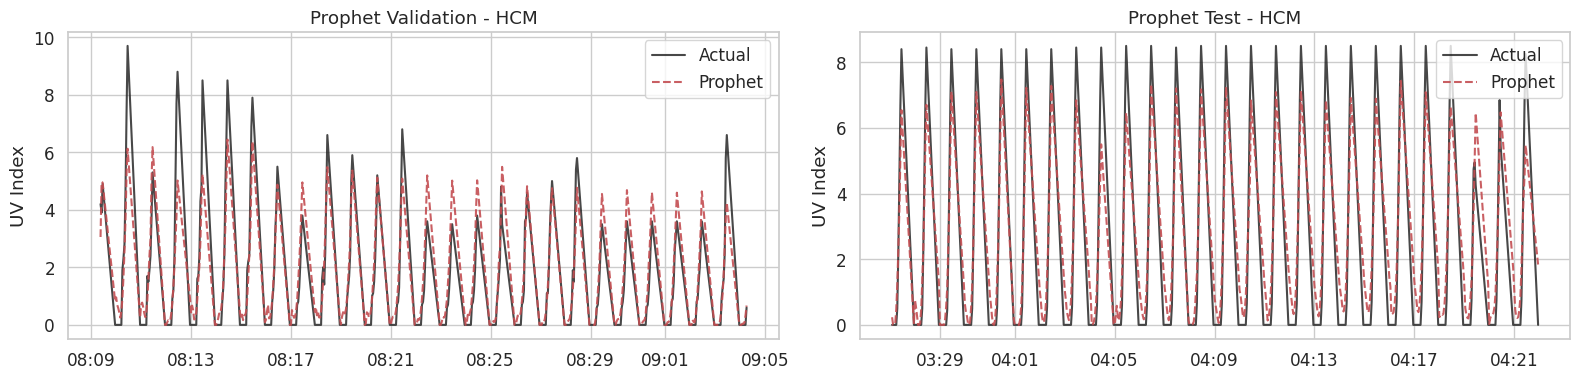

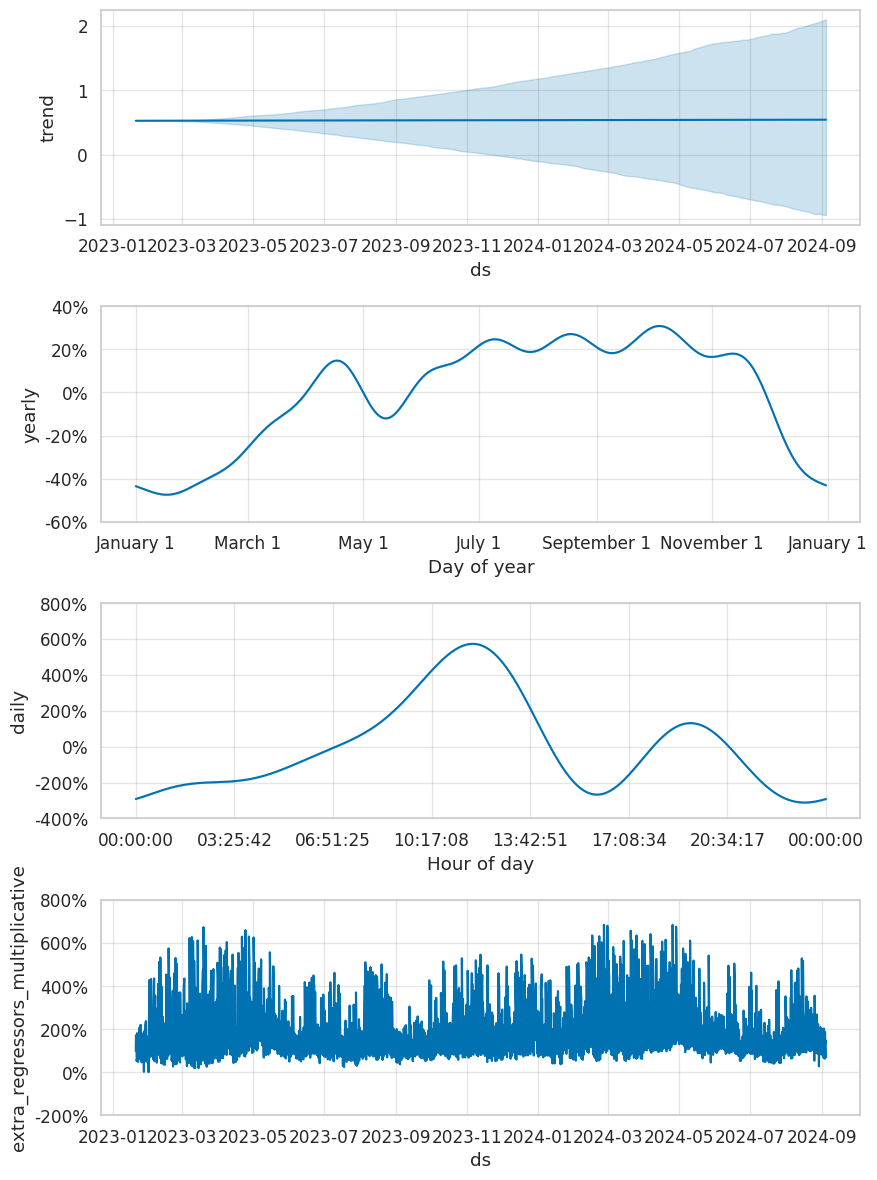

In [4]:
results = {}
def evaluate(name, y_true, y_pred, split='val'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 0.1 ))) * 100
    results[f'{name}_{split}'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}
    print(f' {name} [{split}] MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.2f}')
    return mae, rmse, r2

for loc in LOCATIONS:
    d = loc_data[loc]
    m = prophet_models[loc]
    exog = d['exog']

    pred_train = m.predict(d['train'][['ds'] + exog])['yhat'].values.clip(min=0)
    pred_val = m.predict(d['val'][['ds'] + exog])['yhat'].values.clip(min=0)
    pred_test = m.predict(d['test'][['ds'] + exog])['yhat'].values.clip(min=0)

    evaluate(f'Prophet_{loc}', d['train']['y'].values, pred_train, 'train')
    evaluate(f'Prophet_{loc}', d['y_val'], pred_val, 'val')
    evaluate(f'Prophet_{loc}', d['y_test'], pred_test, 'test')

    d['pred_prophet_train'] = pred_train
    d['pred_prophet_val'] = pred_val
    d['pred_prophet_test'] = pred_test


for split in ['train', 'val', 'test']:
    keys = [k for k in results if k.endswith(f'_{split}')]
    if keys:
        avg = {m: np.mean([results[k][m] for k in keys]) for m in ['MAE', 'RMSE', 'R2']}
        print(f"\n=== Prophet avg {split.upper()} across {len(LOCATIONS)} locations: MAE={avg['MAE']:.4f} RMSE={avg['RMSE']:.4f} R2={avg['R2']:.2f} ===")


demo = loc_data['hcm']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, split, y_true, pred, title in [
    (axes[0], 'val', demo['y_val'], demo['pred_prophet_val'], 'Validation'),
    (axes[1], 'test', demo['y_test'], demo['pred_prophet_test'], 'Test'),
]:
    ax.plot(demo[split]['ds'].values[-336:], y_true[-336:], 'k-', alpha=0.8, linewidth=1.5, label='Actual')
    ax.plot(demo[split]['ds'].values[-336:], pred[-336:], 'r--', alpha=0.9, linewidth=1.5, label='Prophet')
    ax.set_title(f'Prophet {title} - HCM')
    ax.set_ylabel('UV Index')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m:%d'))
plt.tight_layout()
plt.show()

fig = prophet_models['hcm'].plot_components(prophet_models['hcm'].predict(demo['val'][['ds'] + demo['exog']]))
plt.show()

# 6. Save Models

In [5]:
MODEL_DIR = Path('../../models') / 'legacy'
MODEL_DIR.mkdir(exist_ok=True, parents=True)
for loc in LOCATIONS:
    joblib.dump(prophet_models[loc], MODEL_DIR / f'prophet_{loc}.joblib')

print(f'Saved {len(LOCATIONS)} prophet models to {MODEL_DIR.resolve()}')


Saved 8 prophet models to /home/dat-vu/Desktop/UV_analysis/models/legacy


In [6]:
## export resuult to CSV
import pandas as pd
from pathlib import Path
results_list = []
for key, metrics in results.items():
    if '_' in key:
        parts = key.rsplit('_', 1)
        if len(parts) == 2:
            model_name, split = parts
        else:
            model_name = key
            split = 'unknown'
    else:
        model_name = key
        split = metrics.get('split', 'unknown')

    results_list.append({
        'notebook': 'regression',
        'model': model_name,
        'split': split,
        'MAE': metrics.get('MAE'),
        'RMSE': metrics.get('RMSE'),
        'R2': metrics.get('R2'),
        'MAPE': metrics.get('MAPE')
    })

results_df = pd.DataFrame(results_list)

results_dir = Path('../../results')
results_dir.mkdir(exist_ok=True)
results_df.to_csv(results_dir / 'modern_results.csv', index=False)
print('SAVED REGRESSION RESULTS')

SAVED REGRESSION RESULTS
